#### 29.10.25, &copy; [Evhenii Kostin](https://github.com/DE123MasterProgram2025autumn/DE_Kostin), 2025

# Лабораторна робота №6: Ефективна робота з великими даними за допомогою пакета data.table


__Мета:__ _освоїти сучасний інструмент для роботи з великими обсягами даних у R — пакет data.table. Навчитися виконувати швидкі, пам’ять-ефективні операції над мільйонами рядків: фільтрацію, агрегацію, оновлення, злиття — з використанням унікального синтаксису DT[i, j, by]. Зрозуміти, чому data.table є ключовим інструментом інженера даних при роботі з великими даними._

### Варіант 2
#### Тема: Аналіз електронної комерції за 2024 рік

In [1]:
# --- 0. ПІДКЛЮЧЕННЯ БІБЛІОТЕК ТА СИМУЛЯЦІЯ ---

# Встановлюємо пакети, якщо їх немає
if (!require("data.table")) install.packages("data.table")
if (!require("ggplot2")) install.packages("ggplot2") # Для Етапу 6

library(data.table)
library(ggplot2)

# Створюємо папку для даних
dir.create("data", showWarnings = FALSE)

# --- Симуляція 1: products.csv ---
message("Створення products.csv...")
set.seed(123)
product_count <- 100
products_dt <- data.table(
  product_id = paste0("P", 1000:(1000 + product_count - 1)),
  product_name = paste("Product", 1:product_count),
  category = sample(c("Electronics", "Clothing", "Home", "Books"), product_count, replace = TRUE),
  brand = sample(c("Brand_A", "Brand_B", "Brand_C"), product_count, replace = TRUE),
  price = round(runif(product_count, 10, 1000), 2)
)
# Записуємо файл
fwrite(products_dt, "data/products.csv")

# --- Симуляція 2: sales_2024.csv ---
message("Створення sales_2024.csv (500,000 рядків)...")
n_rows <- 500000
sales_dt <- data.table(
  order_id = 1:n_rows,
  customer_id = paste0("C", sample(1:50000, n_rows, replace = TRUE)),
  product_id = sample(products_dt$product_id, n_rows, replace = TRUE),
  quantity = sample(1:5, n_rows, replace = TRUE),
  order_date = sample(
    seq(as.IDate("2024-01-01"), as.IDate("2024-12-31"), by = "day"),
    n_rows,
    replace = TRUE
  )
)
# Записуємо файл
fwrite(sales_dt, "data/sales_2024.csv")

message("--- ЕТАП 0 ЗАВЕРШЕНО. Файли створено. ---")

Loading required package: data.table

Loading required package: ggplot2

Створення products.csv...

Створення sales_2024.csv (500,000 рядків)...

--- ЕТАП 0 ЗАВЕРШЕНО. Файли створено. ---



### Етап 1: Завантаження даних
- Завантажити sales_2024.csv через fread().
- Завантажити products.csv через fread().
- Переконатися, що обидва об’єкти є data.table.

In [2]:
# --- Етап 1: Завантаження даних ---
message("--- ЕТАП 1: ЗАВАНТАЖЕННЯ ДАНИХ ---")

# 1.1 Завантажуємо sales_2024.csv
sales_dt <- fread("data/sales_2024.csv")
message(paste("sales_2024.csv завантажено. Клас:", class(sales_dt)[1]))
print(head(sales_dt, 3))

# 1.2 Завантажуємо products.csv
products_dt <- fread("data/products.csv")
message(paste("\nproducts.csv завантажено. Клас:", class(products_dt)[1]))
print(head(products_dt, 3))

message("--- ЕТАП 1 ЗАВЕРШЕНО. ---")

--- ЕТАП 1: ЗАВАНТАЖЕННЯ ДАНИХ ---

sales_2024.csv завантажено. Клас: data.table

   order_id customer_id product_id quantity order_date
      <int>      <char>     <char>    <int>     <IDat>
1:        1       C7826      P1033        2 2024-10-07
2:        2      C14751      P1083        4 2024-02-16
3:        3      C24263      P1099        2 2024-08-19

products.csv завантажено. Клас: data.table

   product_id product_name category   brand  price
       <char>       <char>   <char>  <char>  <num>
1:      P1000    Product 1     Home Brand_A 551.36
2:      P1001    Product 2     Home Brand_B 665.69
3:      P1002    Product 3     Home Brand_A 179.98
--- ЕТАП 1 ЗАВЕРШЕНО. ---



### Етап 2: Підготовка даних
- Додати стовпець revenue = quantity * price на місці через :=.
- Видалити стовпці order_id, customer_id на місці.
- Перетворити order_date на Date (якщо потрібно).

In [3]:
# --- Етап 2: Підготовка даних ---
message("--- ЕТАП 2: ПІДГОТОВКА ДАНИХ ---")

# Примітка: Інструкція Етапу 2 вимагає `revenue = quantity * price`.
# 'price' знаходиться у 'products_dt', тому ми *спочатку* об'єднаємо таблиці.
message("Об'єднання sales_dt та products_dt...")
sales_dt <- merge(sales_dt, products_dt, by = "product_id")

# 2.1 Додаємо стовпець revenue НА МІСЦІ (:=)
message("Обчислення 'revenue' на місці...")
sales_dt[, revenue := quantity * price]

# 2.2 Видаляємо стовпці order_id та customer_id НА МІСЦІ (:= NULL)
message("Видалення 'order_id' та 'customer_id' на місці...")
sales_dt[, c("order_id", "customer_id") := NULL]

# 2.3 Перетворюємо order_date на IDate (швидкий формат дати data.table)
# (Він вже може бути IDate, якщо fread() його розпізнав, але для певності)
message("Перетворення 'order_date' на IDate...")
sales_dt[, order_date := as.IDate(order_date)]

message("\nРезультат Етапу 2 (об'єднані та очищені дані):")
print(head(sales_dt, 3))

message("--- ЕТАП 2 ЗАВЕРШЕНО. ---")

--- ЕТАП 2: ПІДГОТОВКА ДАНИХ ---

Об'єднання sales_dt та products_dt...

Обчислення 'revenue' на місці...

Видалення 'order_id' та 'customer_id' на місці...

Перетворення 'order_date' на IDate...


Результат Етапу 2 (об'єднані та очищені дані):

Key: <product_id>
   product_id quantity order_date product_name category   brand  price revenue
       <char>    <int>     <IDat>       <char>   <char>  <char>  <num>   <num>
1:      P1000        5 2024-12-01    Product 1     Home Brand_A 551.36 2756.80
2:      P1000        1 2024-04-12    Product 1     Home Brand_A 551.36  551.36
3:      P1000        1 2024-04-23    Product 1     Home Brand_A 551.36  551.36
--- ЕТАП 2 ЗАВЕРШЕНО. ---



### Етап 3: Агрегація за категоріями та брендами
- Об’єднати sales з products через on = "product_id".
- Для кожної комбінації category та brand обчислити:
- - загальний дохід (total_revenue),
- - кількість унікальних продуктів (.N),
- - середню ціну (mean(price)).
- Використати by = .(category, brand).
- Відсортувати результат за спаданням total_revenue через keyby.

In [4]:
# --- Етап 3: Агрегація за категоріями та брендами ---
message("--- ЕТАП 3: АГРЕГАЦІЯ ЗА КАТЕГОРІЯМИ ТА БРЕНДАМИ ---")

# Інструкція "Об’єднайте sales з products" вже виконана в Етапі 2.
# Тепер виконуємо агрегацію:
agg_brand_category <- sales_dt[, .(
    total_revenue = sum(revenue),
    n_products = .N, # .N - кількість рядків у групі (кількість продажів)
    mean_price = mean(price)
  ), 
  keyby = .(category, brand) # keyby = групує ТА сортує за category, brand
]

# Відсортуємо результат за спаданням total_revenue
setorder(agg_brand_category, -total_revenue)

message("Результат Етапу 3 (агрегація за категорією та брендом):")
print(head(agg_brand_category, 10))

message("--- ЕТАП 3 ЗАВЕРШЕНО. ---")

--- ЕТАП 3: АГРЕГАЦІЯ ЗА КАТЕГОРІЯМИ ТА БРЕНДАМИ ---

Результат Етапу 3 (агрегація за категорією та брендом):

       category   brand total_revenue n_products mean_price
         <char>  <char>         <num>      <int>      <num>
 1: Electronics Brand_C      98229376      65181   501.4081
 2:    Clothing Brand_B      88306769      54892   533.4493
 3: Electronics Brand_B      87401129      49949   584.3249
 4:        Home Brand_C      86853928      44952   646.8629
 5:        Home Brand_B      80621287      54776   491.3676
 6:    Clothing Brand_C      63318561      44888   468.6343
 7:        Home Brand_A      52247786      44909   386.9067
 8:       Books Brand_B      44582175      35280   419.5289
 9:       Books Brand_A      43349159      29990   484.7742
10:    Clothing Brand_A      42043078      30003   465.5043
--- ЕТАП 3 ЗАВЕРШЕНО. ---



### Етап 4: Аналіз за місяцями
- Створити стовпець month = format(order_date, "%Y-%m").
- Для кожної категорії обчислити місячний дохід.
- Використати .SD та .SDcols = "revenue" для агрегації.

In [5]:
# --- Етап 4: Аналіз за місяцями ---
message("--- ЕТАП 4: АНАЛІЗ ЗА МІСЯЦЯМИ ---")

# 4.1 Створюємо стовпець month НА МІСЦІ
message("Додавання стовпця 'month'...")
sales_dt[, month := format(order_date, "%Y-%m")]

# 4.2 Обчислюємо місячний дохід за категорією, використовуючи .SD
# .SD (Subset of Data) - це data.table, що містить дані поточної групи
# .SDcols вказує, які стовпці включити в .SD
message("Розрахунок місячного доходу за категоріями...")
monthly_revenue_agg <- sales_dt[, 
    lapply(.SD, sum), # Застосовуємо sum до .SD
    by = .(category, month),
    .SDcols = "revenue" # Включаємо в .SD лише 'revenue'
]

# Перейменуємо стовпець для ясності
setnames(monthly_revenue_agg, "revenue", "monthly_total_revenue")
setorder(monthly_revenue_agg, category, month)

message("\nРезультат Етапу 4 (місячний дохід):")
print(head(monthly_revenue_agg, 10))

message("--- ЕТАП 4 ЗАВЕРШЕНО. ---")

--- ЕТАП 4: АНАЛІЗ ЗА МІСЯЦЯМИ ---

Додавання стовпця 'month'...

Розрахунок місячного доходу за категоріями...


Результат Етапу 4 (місячний дохід):

    category   month monthly_total_revenue
      <char>  <char>                 <num>
 1:    Books 2024-01              10212059
 2:    Books 2024-02               9423400
 3:    Books 2024-03              10382006
 4:    Books 2024-04               9860140
 5:    Books 2024-05              10260808
 6:    Books 2024-06               9927019
 7:    Books 2024-07              10352537
 8:    Books 2024-08              10266728
 9:    Books 2024-09               9781532
10:    Books 2024-10              10148077
--- ЕТАП 4 ЗАВЕРШЕНО. ---



### Етап 5: Топ-5 продуктів за доходом
- Зберегти високоефективні кампанії (ROI > 0.5) у файли за допомогою walk2() (наприклад, high_roi_01.csv, high_roi_02.csv, …).

In [6]:
# --- Етап 5: Топ-5 продуктів за доходом ---
message("--- ЕТАП 5: ПОШУК ТОП-5 ПРОДУКТІВ ---")

# 5.1 Обчислюємо загальний дохід за product_id
top_products_agg <- sales_dt[,
    .(total_revenue = sum(revenue)),
    by = .(product_id, product_name) # Включаємо name, щоб не робити merge
]

# 5.2 Сортуємо та вибираємо Топ-5
setorder(top_products_agg, -total_revenue)
top_5_products <- top_products_agg[1:5]
# Або так: top_5_products <- head(top_products_agg, 5)

message("Результат Етапу 5 (Топ-5 продуктів):")
print(top_5_products)

message("--- ЕТАП 5 ЗАВЕРШЕНО. ---")

--- ЕТАП 5: ПОШУК ТОП-5 ПРОДУКТІВ ---

Результат Етапу 5 (Топ-5 продуктів):

   product_id product_name total_revenue
       <char>       <char>         <num>
1:      P1086   Product 87      14994148
2:      P1007    Product 8      14901735
3:      P1099  Product 100      14687677
4:      P1056   Product 57      14612010
5:      P1008    Product 9      14520639
--- ЕТАП 5 ЗАВЕРШЕНО. ---



### Етап 6: Візуалізація (опціонально)
- Перетворити результат на data.frame через setDF().
- Побудувати графік дохідності категорій (через ggplot2).

--- ЕТАП 6: ВІЗУАЛІЗАЦІЯ ---

Перетворення на data.frame для ggplot2...

--- ЛАБОРАТОРНУ РОБОТУ ЗАВЕРШЕНО. ---



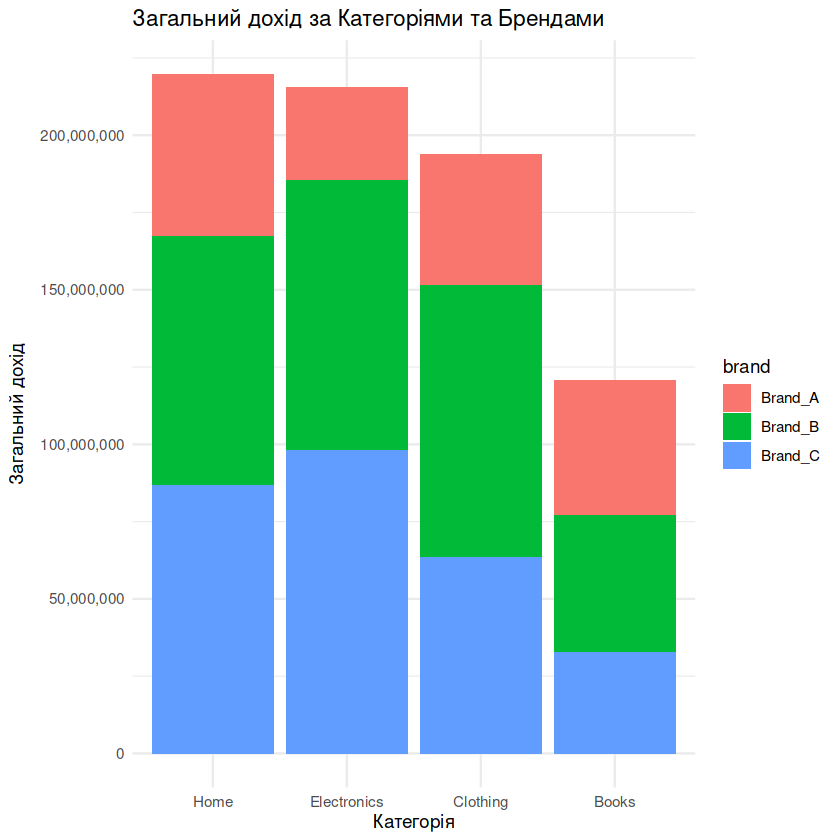

In [7]:
# --- Етап 6: Візуалізація (опціонально) ---
message("--- ЕТАП 6: ВІЗУАЛІЗАЦІЯ ---")

# 6.1 Беремо дані з Етапу 3
plot_data <- agg_brand_category

# 6.2 Перетворюємо data.table на data.frame НА МІСЦІ
message("Перетворення на data.frame для ggplot2...")
setDF(plot_data) 
# (Також можна просто передати data.table в ggplot, він його зрозуміє)

# 6.3 Будуємо графік
p <- ggplot(plot_data, aes(x = reorder(category, -total_revenue), y = total_revenue, fill = brand)) +
  geom_col(position = "stack") +
  labs(
    title = "Загальний дохід за Категоріями та Брендами",
    x = "Категорія",
    y = "Загальний дохід"
  ) +
  theme_minimal() +
  scale_y_continuous(labels = scales::comma) # Для кращого форматування чисел

print(p)
message("--- ЛАБОРАТОРНУ РОБОТУ ЗАВЕРШЕНО. ---")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6a083947-94ba-475d-8730-27cff0574f54' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>